In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from scipy.stats import chi2_contingency
import re
import src.fct_data
import importlib
importlib.reload(src.fct_data) 

from src.fct_data import raw_data_cleaning


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Extraction des données



Traitement pour les 3 années disponibles sur le `gitlab` 

In [2]:
#on récupère un df avec métadonnées + texte nettoyé des stopwords
meta_et_texts=raw_data_cleaning("data/archelect_search.zip","data/text_files")

/home/onyxia/work/NLP_3A/src/fct_data.py:12: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  metadonnees = pd.read_csv("data/archelect_search.zip", compression="zip")


Traitement de data/text_files/1988/legislatives.zip
Traitement de data/text_files/1981/legislatives.zip
Traitement de data/text_files/1993/legislatives.zip
Traitement de data/text_files/1993/presidentielle.zip
Nombre total de documents extraits : 12746


[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## [NEW] Identifcation des thèmes pour l'élection 1981

### Première approche : BoW + IDF 

Pour montrer que ça ne marche pas bien pcq on rate les thèmes

In [3]:
#1981
texts_1981 = meta_et_texts[meta_et_texts['annee'] == 1981]
print(f"Nombre de documents 1981 : {len(texts_1981)}")

#on selectionne les partis présentants le plus de candidats
parti_counts = texts_1981['suppleant-soutien'].value_counts()
parti_counts = parti_counts.drop("non mentionné", errors='ignore')
top_partis = parti_counts.head(6).index.tolist()

rows=[]

#matrice BoW IDF
vectorizer = TfidfVectorizer(
    stop_words=None,   
    max_features=30    # garder les 30 mots les plus fréquents
)

for parti in top_partis:
    # Filtrer les textes de ce parti
    texts_parti = texts_1981[texts_1981['suppleant-soutien'] == parti]['texte_clean']
    
    idf_matrix = vectorizer.fit_transform(texts_parti)

    idf_df = pd.DataFrame(idf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
    top_parti = idf_df.mean(axis=0).sort_values(ascending=False).index.tolist()
      # Ajouter au tableau
    rows.append({
        "parti": parti,
        "top_words": top_parti
    })


top_words_df = pd.DataFrame(rows)
top_words_df['top_words'] = top_words_df['top_words'].apply(lambda x: ", ".join(x))
top_words_df

Nombre de documents 1981 : 3121


,parti,top_words
0,Parti socialiste,"france, socialiste, majorité, plus, politique,..."
1,Parti communiste français,"gauche, majorité, changement, communistes, com..."
2,Lutte ouvrière,"gauche, mitterrand, faut, travailleurs, plus, ..."
3,Parti socialiste unifié,"psu, majorité, gauche, cest, plus, politique, ..."
4,Rassemblement pour la République,"france, plus, politique, fonds, po, majorité, ..."
5,Rassemblement pour la République;Union pour la...,"plus, majorité, france, juin, candidat, politi..."


## Représentation textuelle

Prend environ 2min grâce à la parallélisation

In [ ]:
import time
import numpy as np
from joblib import Parallel, delayed
import math

# -----------------------------
# 1️⃣ Charger le modèle CamemBERT
# -----------------------------
device = 'cpu'  # ou 'cuda' si GPU disponible
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

# -----------------------------
# 2️⃣ Paramètres
# -----------------------------
texts = meta_et_texts['texte_clean'].tolist()  # liste des textes
chunk_size = 1000       # taille des chunks pour parallélisation
batch_size = 2048       # batch_size à l'intérieur du modèle
num_cores = 48          # nombre de threads CPU à utiliser pour joblib

# découper en chunks
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]
num_chunks = len(chunks)

print(f"Nombre total de chunks : {num_chunks}")

# -----------------------------
# 3️⃣ Fonction pour encoder un chunk
# -----------------------------
def encode_chunk(chunk, chunk_idx):
    start = time.time()
    embeddings = model.encode(chunk, batch_size=batch_size, convert_to_numpy=True)
    end = time.time()
    elapsed = end - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed

# -----------------------------
# 4️⃣ Encodage parallèle avec suivi du temps
# -----------------------------
start_total = time.time()

results = Parallel(n_jobs=num_cores)(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

# Séparer embeddings et temps par chunk
embeddings_list = [res[0] for res in results]
chunk_times = [res[1] for res in results]

# Concaténer tous les embeddings
embeddings = np.vstack(embeddings_list)
total_time = time.time() - start_total

# -----------------------------
# 5️⃣ Affichage final
# -----------------------------
print(f"\n✅ Embeddings générés pour {len(texts)} textes !")
print(f"Shape des embeddings : {embeddings.shape}")
print(f"Temps total écoulé : {total_time/60:.2f} minutes")
print(f"Temps moyen par chunk : {np.mean(chunk_times):.2f} secondes")
print(f"Temps estimé si encore {num_chunks} chunks : {np.mean(chunk_times)*(num_chunks-1)/60:.2f} minutes")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 753.35it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Nombre total de chunks : 13
✅ Chunk 1/13 traité en 57.37s
✅ Chunk 3/13 traité en 53.31s
✅ Chunk 2/13 traité en 57.74s
✅ Chunk 4/13 traité en 55.29s
✅ Chunk 5/13 traité en 54.86s
✅ Chunk 13/13 traité en 36.83s
✅ Chunk 6/13 traité en 54.07s
✅ Chunk 8/13 traité en 50.15s
✅ Chunk 7/13 traité en 55.66s
✅ Chunk 10/13 traité en 49.49s
✅ Chunk 9/13 traité en 54.44s
✅ Chunk 11/13 traité en 49.07s
✅ Chunk 12/13 traité en 50.30s

✅ Embeddings générés pour 12746 textes !
Shape des embeddings : (12746, 384)
Temps total écoulé : 1.48 minutes
Temps moyen par chunk : 52.20 secondes
Temps estimé si encore 13 chunks : 10.44 minutes


## Classification par thème

Ci-dessous, on transforme notre embedding en vecteurs de bcp plus petite dimension (moins d'1min, mais ça dépend des paramètre d'UMAP)

In [36]:
umap_embeddings = umap.UMAP(
    n_neighbors=30, min_dist=0.05, n_components=5, random_state=42
).fit_transform(embeddings)
print(f"UMAP embeddings shape: {umap_embeddings.shape}")

/opt/python/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings shape: (12746, 5)


DBScan ci-dessous va créer des clusters thématiques

In [38]:
print("Clustering avec HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
#on ajoute à notre dataframe le thème abordé par le candidat
meta_et_texts['theme_cluster'] = clusterer.fit_predict(umap_embeddings)
print(f"Clusters trouvés : {meta_et_texts['theme_cluster'].nunique()} (le -1 correspond aux outliers)")


Clustering avec HDBSCAN...
Clusters trouvés : 34 (le -1 correspond aux outliers)


On essaie de labelliser les thèmes automatiquement

In [49]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # ou français

def get_top_words(texts, n=10):
    all_words = " ".join(texts).lower().split()
    # filtrer les stopwords
    all_words = [w for w in all_words if w not in ENGLISH_STOP_WORDS]
    return Counter(all_words).most_common(n)

for cluster_id in sorted(meta_et_texts['theme_cluster'].unique()):
    if cluster_id == -1:  # ignorer les outliers si tu veux
        continue
    texts = meta_et_texts[meta_et_texts['theme_cluster'] == cluster_id]['texte_clean']
    top_words = get_top_words(texts)
    print(f"Cluster {cluster_id}: {top_words}")

Cluster 0: [('quils', 705), ('leurs', 703), ('faire', 640), ('travailleurs', 576), ('cest', 512), ('patrons', 512), ('maintenir', 512), ('entreprises', 448), ('patronat', 448), ('payer', 448)]
Cluster 1: [('quils', 583), ('leurs', 582), ('faire', 530), ('travailleurs', 477), ('cest', 424), ('patrons', 424), ('maintenir', 424), ('entreprises', 371), ('patronat', 371), ('payer', 371)]
Cluster 2: [('cest', 132), ('non', 132), ('pouvons', 110), ('accepter', 110), ('production', 88), ('sortir', 88), ('cela', 88), ('triage', 88), ('quon', 88), ('temps', 88)]
Cluster 3: [('cest', 409), ('non', 408), ('pouvons', 340), ('accepter', 340), ('production', 272), ('cela', 272), ('triage', 272), ('quon', 272), ('temps', 272), ('sortir', 271)]
Cluster 4: [('quils', 649), ('leurs', 649), ('faire', 590), ('travailleurs', 531), ('cest', 472), ('patrons', 472), ('maintenir', 472), ('entreprises', 413), ('patronat', 413), ('payer', 413)]
Cluster 5: [('quils', 374), ('leurs', 374), ('faire', 340), ('travail

## Croisement avec les professions des candidats

Analyse exploratoire

In [13]:
meta_et_texts['titulaire-profession'].nunique()

2032

On a 2032 professions différentes, pas vraiment d'organisation ou de nomenclature déjà déterminée ; on va donc également utiliser de l'embedding et du clustering pour attribuer aux candidats une catégorie plus vaste de métier

In [ ]:
#cleaning en préambule
professions = meta_et_texts['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    #la ligne ci-dessous permet de supprimer le point-virgule séparant les différents métiers déclarés par une même personne
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

def clean_prof(x):
    x = re.sub(r"[^\w\s-]", "", x)
    return x

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

2029

In [ ]:
#Embedding des métiers
model_professions = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings_professions = model_professions.encode(unique_professions,batch_size=256,show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 971.46it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 8/8 [01:31<00:00, 11.45s/it]


In [ ]:
from sklearn.cluster import KMeans

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings_professions)
prof_cluster_df = pd.DataFrame({
    "profession": unique_professions,
    "cluster": clusters
})

In [27]:
cluster_map = dict(zip(prof_cluster_df.profession, prof_cluster_df.cluster))

meta_et_texts["profession_clean"] = (
    meta_et_texts["titulaire-profession"]
    .str.lower()
    .str.strip()
)

meta_et_texts["profession_cluster"] = (
    meta_et_texts["profession_clean"]
    .map(cluster_map)
)

In [28]:
#Analyse des clusters
for i in range(n_clusters):
    print("\nCluster", i)
    print(prof_cluster_df[prof_cluster_df.cluster == i].profession.tolist())


Cluster 0
['ingénieur', 'technicien cadre multinationale', 'ingénieur informaticien', 'ingénieur-conseil urbaniste', 'technicien', 'ingénieur industrie', 'agréé architecture', 'ingénieur divisionnaire', 'directeur technique cnasea', 'ingénieur chimiste', 'architecte', 'technicienne recherche', 'ingénieur commercial informatique', 'ingénieur civil', 'ingénieur économiste', 'architecte-urbaniste', 'ingénieur président centre de formation professionnelle', 'ingénieur-conseil', 'électronicien', 'ingénieur en chef ponts et chaussées', 'technicien tdf', 'ingénieur ponts et chaussées', 'ingénieur électronicien', 'ingénieur détudes université', 'chauffeur chaudière', 'responsable industriel', 'ingénieur civil ponts et chaussées administrateur insee', 'conducteur de travaux', 'ouvrier électricien', 'ingénieur thermicien assimilé', 'technicien atelier', 'ouvrier métallurgiste', 'architecte dplg', 'ingénieur industriel', 'ingénieur commercial', 'ouvrier laboratoire photographique', 'technicien p

In [29]:
cluster_labels = {
0: "ingenieur",
1: "commercant_cadre_commercial",
2: "chef",
3: "technicien",
4: "legal",
5: "artisan_artistique",
6: "education_nationale",
7: "agriculture",
8: "medecine",
9: "professions_intell_superieures",
10: "militaire",
11: "divers"
}

On ajoute les catégories des métiers au dataframe de base

In [30]:
meta_et_texts["profession_category"] = (
    meta_et_texts["profession_cluster"]
    .map(cluster_labels)
)

### Analyse conjointe des sujets des professions de foi et des métiers

In [39]:
pd.crosstab(
    meta_et_texts["profession_category"],
    meta_et_texts["theme_cluster"],
    normalize="index"
)

theme_cluster,-1,0,1,2,3,4,5,6,7,8,...,21,22,25,26,27,28,29,30,31,32
profession_category,,,,,,,,,,,,,,,,,,,,,
agriculture,0.012346,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.006173,0.000000,0.000000,0.000000,0.000000,0.833333
artisan_artistique,0.053846,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007692,...,0.000000,0.000000,0.015385,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.815385
chef,0.035849,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001887,0.000000,0.001887,...,0.000000,0.000000,0.007547,0.000000,0.007547,0.003774,0.000000,0.001887,0.000000,0.824528
commercant_cadre_commercial,0.048387,0.008065,0.010753,0.000000,0.000000,0.005376,0.000000,0.005376,0.000000,0.005376,...,0.000000,0.000000,0.000000,0.002688,0.002688,0.000000,0.000000,0.000000,0.000000,0.793011
divers,0.047143,0.007881,0.006333,0.003096,0.009569,0.006896,0.004222,0.003940,0.007740,0.001126,...,0.002815,0.008725,0.001267,0.003940,0.003237,0.001829,0.000281,0.008303,0.002955,0.813397
education_nationale,0.035484,0.000000,0.000000,0.000000,0.000000,0.003226,0.000000,0.004301,0.000000,0.000000,...,0.001075,0.000000,0.002151,0.001075,0.002151,0.003226,0.000000,0.000000,0.000000,0.907527
ingenieur,0.043845,0.003373,0.003373,0.000000,0.000000,0.003373,0.005059,0.000000,0.003373,0.000000,...,0.000000,0.000000,0.005059,0.001686,0.001686,0.006745,0.000000,0.001686,0.000000,0.829680
legal,0.031161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005666,...,0.000000,0.000000,0.008499,0.000000,0.002833,0.000000,0.000000,0.000000,0.000000,0.906516
medecine,0.033278,0.001664,0.001664,0.000000,0.000000,0.003328,0.001664,0.001664,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003328,0.000000,0.870216


-1 étant la catégorie "outlier", on a clairement pas un résultat fou

##### Visualisation

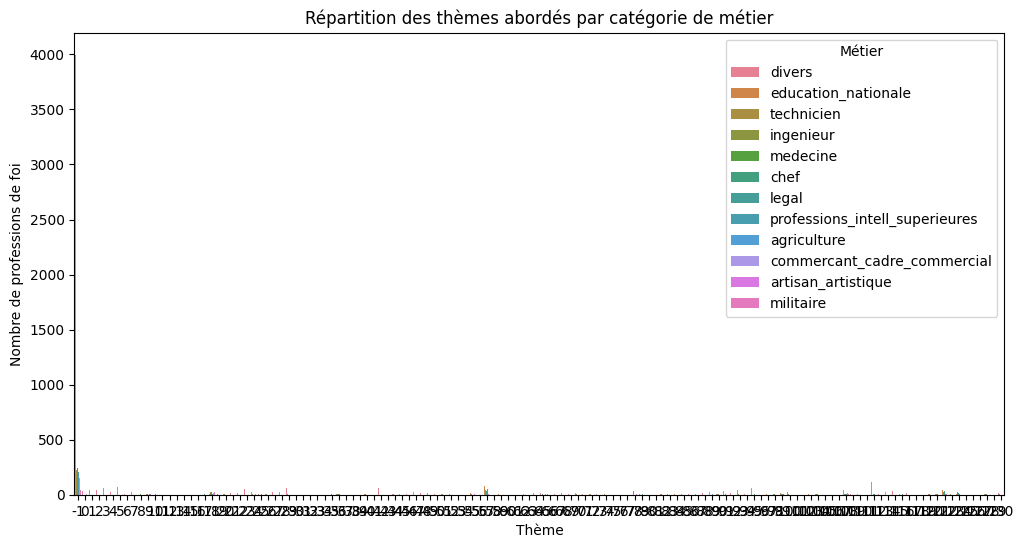

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(x='theme_cluster', hue='profession_category', data=meta_et_texts)
plt.title("Répartition des thèmes abordés par catégorie de métier")
plt.xlabel("Thème")
plt.ylabel("Nombre de professions de foi")
plt.legend(title="Métier")
plt.show()

Beaucoup trop de thèmes pour permettre une analyse

## Analyses statistiques diverses

In [34]:
print(meta_et_texts.columns)

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'text',
       'zip_path', 'texte_clean', 'annee', 'theme_cluster

In [35]:
contingency_table = pd.crosstab(meta_et_texts['profession_category'], meta_et_texts['theme_cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi2 = 3359.66, p-value = 0.0000
